In [1]:
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
from plot_pca import plot_pca_loadings
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime

from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients.csv')
behavior_table

,ptID,trial_idx,nrs_raw,vasp_raw,somatic_raw,unpleasantness_raw,affective_raw,vasd_raw,nrs_z,vasp_z,somatic_z,unpleasantness_z,affective_z,vasd_r_z,pca_sensory_PC1,pca_affective_PC1
0,RCS02,32,3.0,38.0,6.0,50.0,1.0,59.0,-1.572153,-2.331655,-1.537004,-0.944105,-0.653720,0.857070,-3.148555,-0.184285
1,RCS02,33,5.0,52.0,7.0,63.0,1.0,68.0,0.060467,-0.731112,-1.256605,0.075528,-0.653720,-0.353790,-1.063422,-0.692122
2,RCS02,34,5.0,57.0,8.0,70.0,2.0,60.0,0.060467,-0.159490,-0.976205,0.624562,-0.065372,0.722530,-0.576758,0.541736
3,RCS02,35,5.0,60.0,9.0,54.0,11.0,40.0,0.060467,0.183484,-0.695806,-0.630372,5.229764,3.413329,-0.225095,5.890015
4,RCS02,36,6.0,57.0,15.0,54.0,0.0,55.0,0.876777,-0.159490,0.986590,-0.630372,-1.242069,1.395229,0.962826,-0.222151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,RCS09,145,5.0,49.0,14.0,35.0,NaN,NaN,0.095929,0.044711,-0.084711,0.050901,NaN,NaN,0.033547,0.050901
663,RCS09,146,5.0,50.0,14.0,35.0,NaN,NaN,0.095929,0.086111,-0.084711,0.050901,NaN,NaN,0.057536,0.050901
664,RCS09,147,4.0,36.0,6.0,8.0,NaN,NaN,-0.383718,-0.493481,-1.017309,-1.034102,NaN,NaN,-1.089186,-1.034102
665,RCS09,148,3.0,31.0,5.0,6.0,NaN,NaN,-0.863365,-0.700478,-1.133884,-1.114473,NaN,NaN,-1.555070,-1.114473


In [ ]:
behavior_table.columns

Index(['ptID', 'trial_idx', 'nrs_raw', 'vasp_raw', 'somatic_raw',
       'unpleasantness_raw', 'affective_raw', 'vasd_raw', 'nrs_z', 'vasp_z',
       'somatic_z', 'unpleasantness_z', 'affective_z', 'vasd_r_z',
       'pca_sensory_PC1', 'pca_affective_PC1'],
      dtype='object')

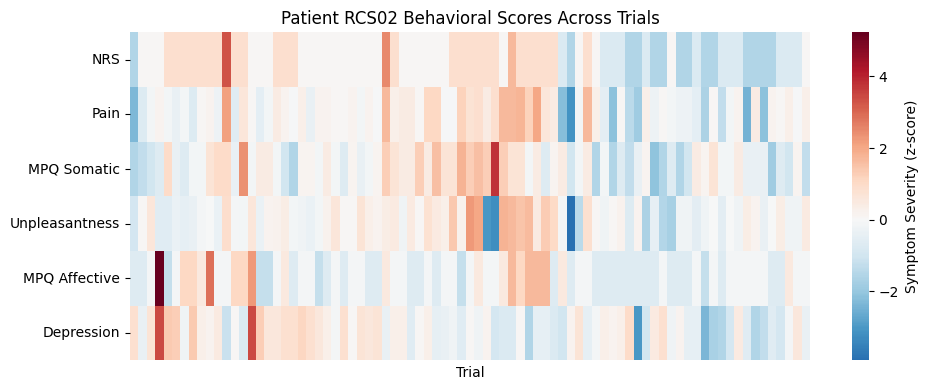

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

ptID = 'RCS02'
behavior_table = behavior_table.rename(columns={'nrs_z':'NRS','vasp_z':'Pain','somatic_z':'MPQ Somatic','unpleasantness_z':'Unpleasantness','affective_z':'MPQ Affective','vasd_r_z':'Depression'})
sub = behavior_table[behavior_table['ptID'] == ptID].sort_values(by='trial_idx')

cols = behavior_table.columns[8:14]
heatmap_data = sub.set_index('trial_idx')[cols].T

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Symptom Severity (z-score)'})
ax.set_xlabel('Trial')
ax.set_ylabel('')
ax.set_xticks([]) 
ax.set_title(f'Patient {ptID} Behavioral Scores Across Trials')
plt.tight_layout()
# plt.savefig(f'{ptID}_zscore_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']
pct_high = 70
pct_low = 30
for ptID in ptIDs:
    subset = behavior_table[behavior_table['ptID']==ptID]
    pc_sens = subset['pca_sensory_PC1']
    pc_aff = subset['pca_affective_PC1']

    sens_thresh = pc_sens.quantile(pct_high / 100)
    aff_thresh = pc_aff.quantile(pct_high / 100)
    
    sens_label = pc_sens > sens_thresh
    aff_label = pc_aff > aff_thresh
    
    overlap_pct = (sens_label & aff_label).sum() / sens_label.sum() * 100
    
    print(f'{ptID}: total trial = {subset.shape[0]}, {overlap_pct:.1f}% of high-sensory trials (top {100-pct_high}%) are also high-affective')

RCS02: 45.8% of high-sensory trials (top 30%) are also high-affective
RCS03: 43.3% of high-sensory trials (top 30%) are also high-affective
RCS04: 76.5% of high-sensory trials (top 30%) are also high-affective
RCS05: 73.7% of high-sensory trials (top 30%) are also high-affective
RCS06: 73.5% of high-sensory trials (top 30%) are also high-affective
RCS07: 81.2% of high-sensory trials (top 30%) are also high-affective
RCS08: 46.7% of high-sensory trials (top 30%) are also high-affective
RCS09: 88.9% of high-sensory trials (top 30%) are also high-affective


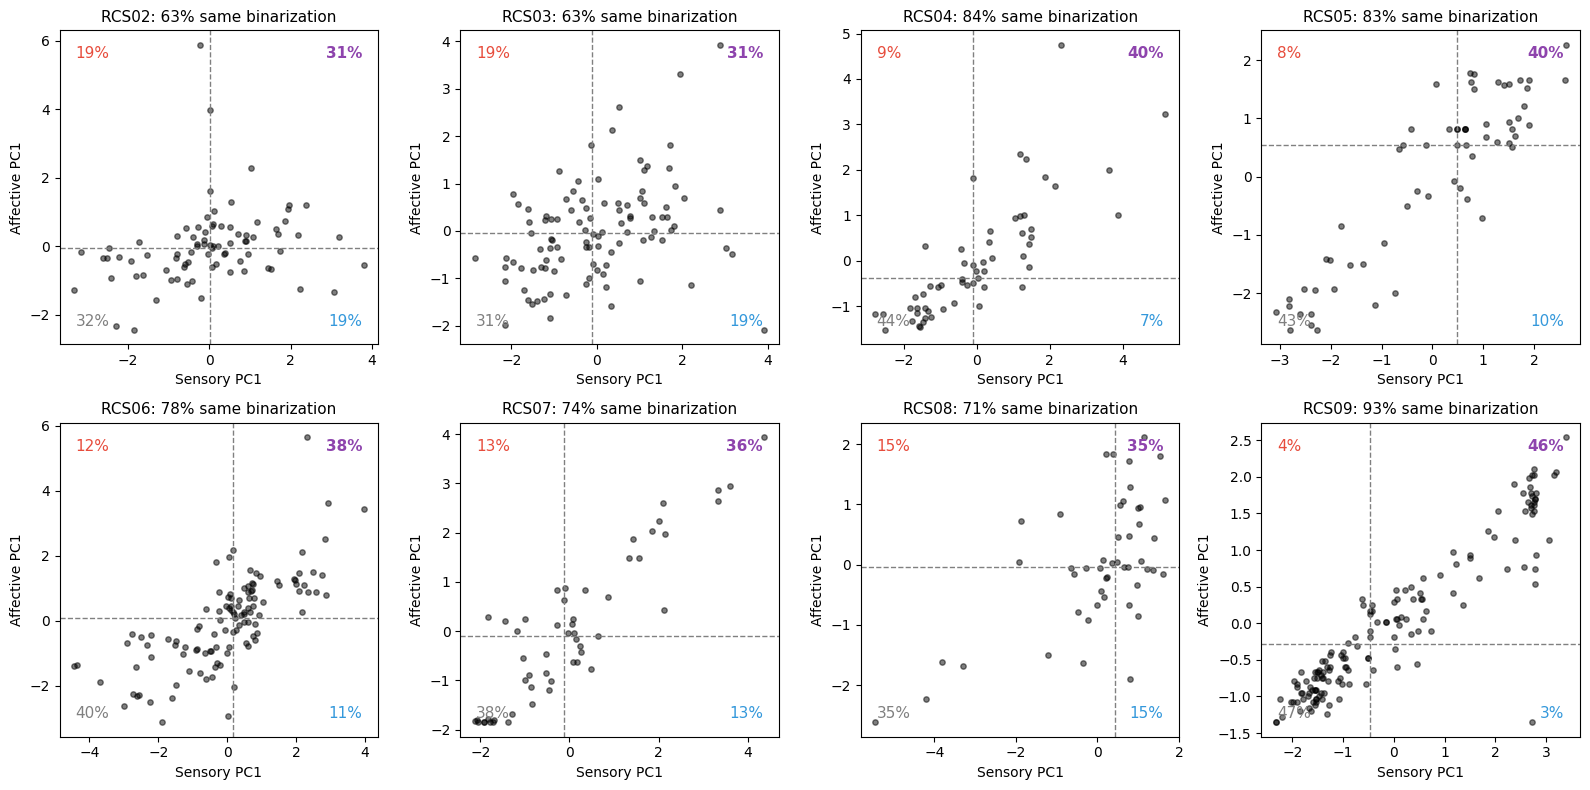

In [15]:
import matplotlib.pyplot as plt

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
pct = 50

n = len(ptIDs)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ptID in enumerate(ptIDs):
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_sens = subset['pca_sensory_PC1']
    pc_aff = subset['pca_affective_PC1']

    # pc_sens = subset['somatic_z']
    # pc_aff = subset['affective_z']
    
    sens_thresh = pc_sens.quantile(pct / 100)
    aff_thresh = pc_aff.quantile(pct / 100)
    
    sens_label = pc_sens > sens_thresh
    aff_label = pc_aff > aff_thresh
    
    ax = axes[i]
    ax.scatter(pc_sens, pc_aff, c='black', alpha=0.5, s=15)
    ax.axvline(sens_thresh, color='gray', linestyle='--', linewidth=1)
    ax.axhline(aff_thresh, color='gray', linestyle='--', linewidth=1)
    
    n_total = len(subset)
    q_high_both = ((sens_label) & (aff_label)).sum() / n_total * 100
    q_high_sens = ((sens_label) & (~aff_label)).sum() / n_total * 100
    q_high_aff = ((~sens_label) & (aff_label)).sum() / n_total * 100
    q_low_both = ((~sens_label) & (~aff_label)).sum() / n_total * 100
    
    xmax, ymax = pc_sens.max(), pc_aff.max()
    xmin, ymin = pc_sens.min(), pc_aff.min()
    
    ax.text(0.95, 0.95, f'{q_high_both:.0f}%', transform=ax.transAxes, ha='right', va='top', fontsize=11, fontweight='bold', color='#8E44AD')
    ax.text(0.05, 0.95, f'{q_high_aff:.0f}%', transform=ax.transAxes, ha='left', va='top', fontsize=11, color='#E74C3C')
    ax.text(0.95, 0.05, f'{q_high_sens:.0f}%', transform=ax.transAxes, ha='right', va='bottom', fontsize=11, color='#3498DB')
    ax.text(0.05, 0.05, f'{q_low_both:.0f}%', transform=ax.transAxes, ha='left', va='bottom', fontsize=11, color='gray')
    
    ax.set_title(f'{ptID}: {q_high_both+q_low_both:.0f}% same binarization', fontsize=11)
    ax.set_xlabel('Sensory PC1')
    ax.set_ylabel('Affective PC1')

    # ax.set_xlabel('MPQ Somatic')
    # ax.set_ylabel('MPQ Affective')

plt.tight_layout()
# plt.savefig('sens_aff_quadrants.png', dpi=300, bbox_inches='tight')
plt.show()

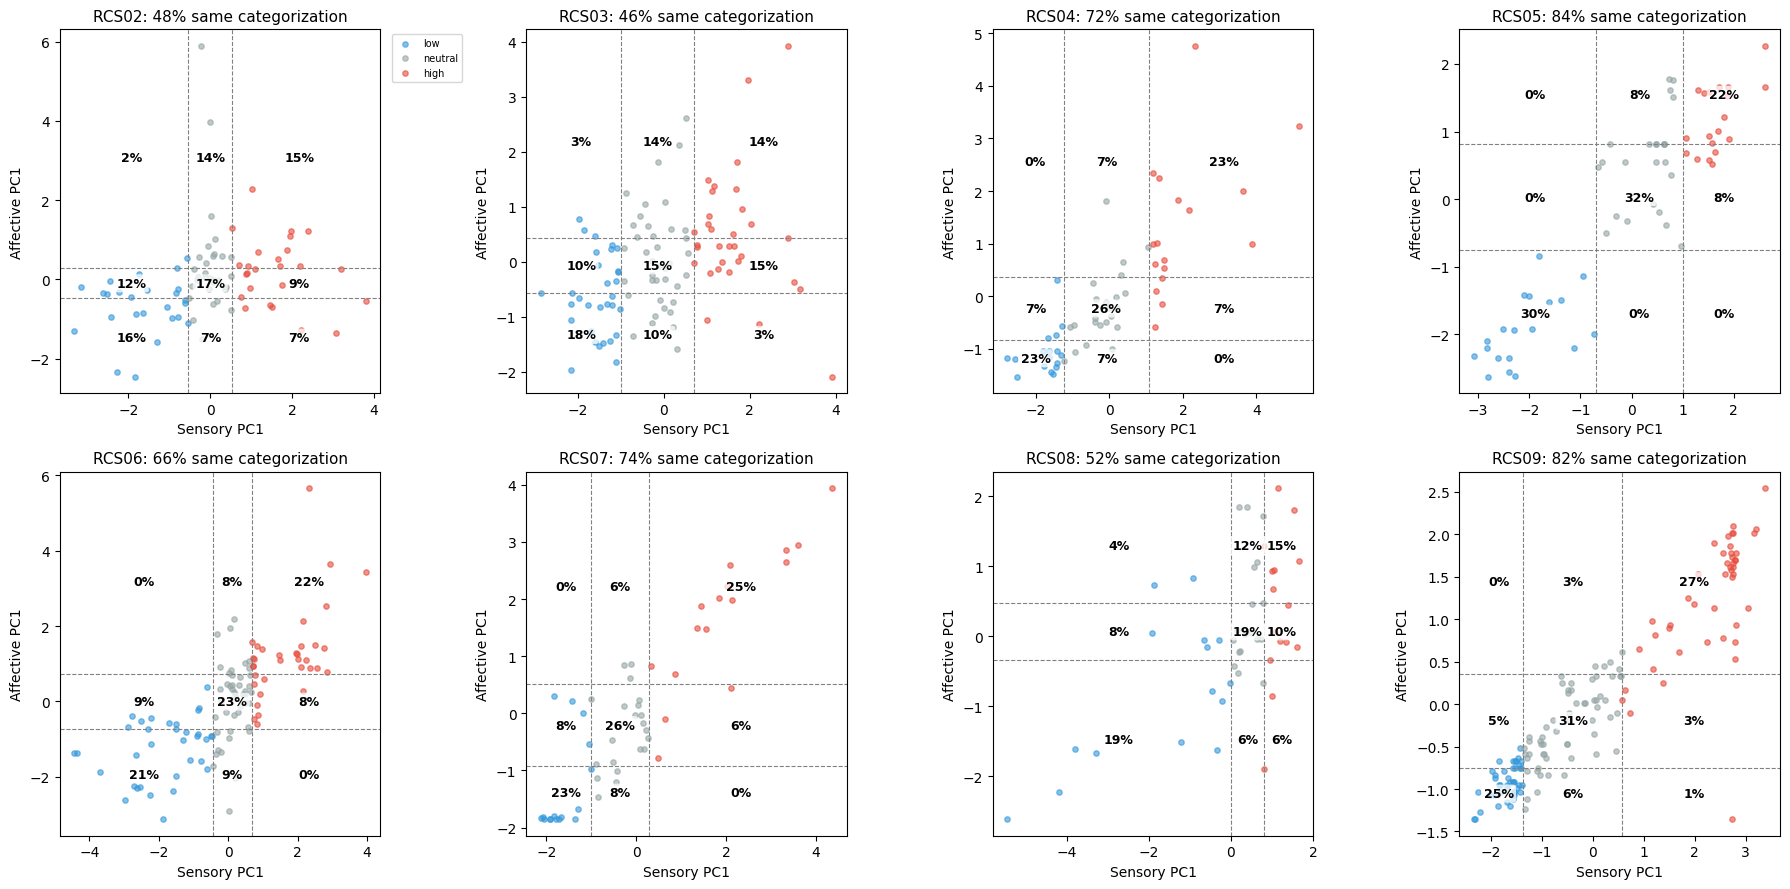

In [11]:
import matplotlib.pyplot as plt
import numpy as np

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
pct = 30

def trisect(series, pct):
    low_thresh = series.quantile(pct / 100)
    high_thresh = series.quantile(1 - pct / 100)
    labels = pd.Series('neutral', index=series.index)
    labels[series <= low_thresh] = 'low'
    labels[series >= high_thresh] = 'high'
    return labels, low_thresh, high_thresh

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

cat_order = ['low', 'neutral', 'high']
color_map = {'low': '#3498DB', 'neutral': '#95A5A6', 'high': '#E74C3C'}

for i, ptID in enumerate(ptIDs):
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_sens = subset['pca_sensory_PC1']
    pc_aff = subset['pca_affective_PC1']
    
    sens_cat, sens_low_t, sens_high_t = trisect(pc_sens, pct)
    aff_cat, aff_low_t, aff_high_t = trisect(pc_aff, pct)
    
    ax = axes[i]
    for cat in cat_order:
        mask = sens_cat == cat
        ax.scatter(pc_sens[mask], pc_aff[mask], c=color_map[cat], alpha=0.6, s=15, label=cat)
    
    ax.axvline(sens_low_t, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(sens_high_t, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(aff_low_t, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(aff_high_t, color='gray', linestyle='--', linewidth=0.8)
    
    x_min, x_max = pc_sens.min(), pc_sens.max()
    y_min, y_max = pc_aff.min(), pc_aff.max()
    
    x_centers = {
        'low': (x_min + sens_low_t) / 2,
        'neutral': (sens_low_t + sens_high_t) / 2,
        'high': (sens_high_t + x_max) / 2
    }
    y_centers = {
        'low': (y_min + aff_low_t) / 2,
        'neutral': (aff_low_t + aff_high_t) / 2,
        'high': (aff_high_t + y_max) / 2
    }
    
    n_total = len(subset)
    pct_same = 0
    for sens_c in cat_order:
        for aff_c in cat_order:
            n_cell = ((sens_cat == sens_c) & (aff_cat == aff_c)).sum()
            pct_cell = n_cell / n_total * 100
            if sens_c == aff_c: pct_same+=pct_cell
            ax.text(x_centers[sens_c], y_centers[aff_c], f'{pct_cell:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))
    
    ax.set_title(f'{ptID}: {pct_same:.0f}% same categorization', fontsize=11)
    ax.set_xlabel('Sensory PC1')
    ax.set_ylabel('Affective PC1')

axes[0].legend(loc='upper left', fontsize=7, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
# plt.savefig('sens_aff_3x3_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.linear_model import LogisticRegressionCV

ptIDs = ['RCS02', 'RCS05', 'RCS08']
pct = 30

cat_order = ['low', 'neutral', 'high']
color_map = {'low': '#3498DB', 'neutral': '#95A5A6', 'high': '#E74C3C'}

def split_dep_new(series, percent1, percent2=None):
    if percent2 == None: percent2 = percent1
    X = np.asarray(series)
    labels = pd.Series(['neutral'] * len(X), index=series.index)
    thresh_low = np.percentile(X, percent1)
    thresh_high = np.percentile(X, 100 - percent2)
    low = np.where(X <= thresh_low)[0]
    high = np.where(X >= thresh_high)[0]
    neutral = np.where((X > thresh_low) & (X < thresh_high))[0]
    labels.iloc[high] = 'high'
    labels.iloc[low] = 'low'
    return labels, len(high), len(neutral), len(low)

results = {}
roi_select = [ 'L dlPFC','R MCC']
for ptID in ['RCS06']:
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_sens = subset['somatic_z']
    pc_aff = subset['affective_z']

    sens_cat, sens_high_num, sens_neu_num, sens_low_num = split_dep_new(pc_sens, 50)
    aff_cat, aff_high_num, aff_neu_num, aff_low_num = split_dep_new(pc_aff, 10,30)

    print('Affective: ', ptID, sum(aff_cat == 'low'), sum(aff_cat == 'high'))
    print('Sensory: ', ptID, sum(sens_cat == 'low'), sum(sens_cat == 'high'))
    subset['aff_label'] = aff_cat
    subset['sens_label'] = sens_cat

    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    # roi_select = list(records_df['roi'].unique())
    merged = records_df.merge(subset,on='trial_idx')
    # merged['aff_label'] = aff_cat
    merged_filt1 = merged[(merged['r2']>=0.9) & (merged['sens_label']!='neutral') & (merged['roi'].isin(roi_select))]
    merged_filt2 = merged[(merged['r2']>=0.9) & (merged['aff_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # Predict affective high/low from somatic z-score, dropping neutral rows
    wide_aff = merged_filt2.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_aff.columns = [f'{feat}_{ch}' for feat, ch in wide_aff.columns]

    wide_sens = merged_filt1.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_sens.columns = [f'{feat}_{ch}' for feat, ch in wide_sens.columns]

    # if the r2 filter drops a channel for some trials, that trial will have NaNs after pivot — drop those trials
    wide_aff = wide_aff.dropna()
    wide_sens = wide_sens.dropna()

    y_aff = merged_filt2.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_aff.index, 'aff_label']
    y_sens = merged_filt1.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_sens.index, 'sens_label']
    X_aff = wide_aff
    X_sens = wide_sens

    clf_aff = LogisticRegressionCV(
        penalty='l2', solver='liblinear',
        cv=5, random_state=42,
        # l1_ratios=[0.0, 0.3, 0.5, 0.7, 1.0],
        Cs=10,
        scoring="accuracy",max_iter=5000
    ).fit(X_aff, y_aff)

    score_aff = clf_aff.score(X_aff, y_aff)
    
    clf_sens = LogisticRegressionCV(
        penalty='l2', solver='liblinear',
        cv=5, random_state=42,
        # l1_ratios=[0.0, 0.3, 0.5, 0.7, 1.0],
        Cs=10,
        scoring="accuracy",max_iter=5000
    ).fit(X_sens, y_sens)

    score_sens = clf_sens.score(X_sens, y_sens)

    print(roi_select)
    print('Affective Logistic Regression:', ptID, 'n_trials:', len(X_aff), 'n_features:', X_aff.shape[1], 'accuracy:', score_aff)
    print('Sensory Logistic Regression:',ptID, 'n_trials:', len(X_sens), 'n_features:', X_sens.shape[1], 'accuracy:', score_sens)
    # results[ptID] = {'clf': clf, 'score': score, 'X': X, 'y': y}

Affective:  RCS06 21 35
Sensory:  RCS06 70 43


/tmp/ipykernel_4052626/2693394257.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['aff_label'] = aff_cat
/tmp/ipykernel_4052626/2693394257.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sens_label'] = sens_cat


['L dlPFC', 'R MCC']
Affective Logistic Regression: RCS06 n_trials: 55 n_features: 12 accuracy: 0.8727272727272727
Sensory Logistic Regression: RCS06 n_trials: 111 n_features: 12 accuracy: 0.7477477477477478


In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.dummy import DummyClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

clf_aff = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        penalty='l2', solver='liblinear',
        cv=5, random_state=42,
        # l1_ratios=[0.0, 0.3, 0.5, 0.7, 1.0],
        Cs=10, scoring='accuracy', max_iter=1000,
    )
)

cv_scores_aff = cross_val_score(clf_aff, X_aff, y_aff, cv=cv, scoring='accuracy')
print('Affective out-of-sample: %.3f ± %.3f' % (cv_scores_aff.mean(), cv_scores_aff.std()))

dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_aff, y_aff, cv=cv, scoring='accuracy')
print('Dummy baseline: %.3f ± %.3f' % (dummy_scores.mean(), dummy_scores.std()))

Affective out-of-sample: 0.747 ± 0.063
Dummy baseline: 0.636 ± 0.023


In [9]:
from sklearn.model_selection import permutation_test_score, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

score, perm_scores, pvalue = permutation_test_score(
    clf_aff, X_aff, y_aff, cv=cv, scoring='accuracy',
    n_permutations=500, random_state=42
)
print(f'Affective: true={score:.3f}, permuted mean={perm_scores.mean():.3f}, p={pvalue:.4f}')

Affective: true=0.747, permuted mean=0.578, p=0.0040


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import permutation_test_score, StratifiedKFold

ptIDs = ['RCS02', 'RCS05', 'RCS08']
pct = 30

cat_order = ['low', 'neutral', 'high']
color_map = {'low': '#3498DB', 'neutral': '#95A5A6', 'high': '#E74C3C'}

def split_dep_new(series, percent1, percent2=None):
    if percent2 == None: percent2 = percent1
    X = np.asarray(series)
    labels = pd.Series(['neutral'] * len(X), index=series.index)
    thresh_low = np.percentile(X, percent1)
    thresh_high = np.percentile(X, 100 - percent2)
    low = np.where(X <= thresh_low)[0]
    high = np.where(X >= thresh_high)[0]
    neutral = np.where((X > thresh_low) & (X < thresh_high))[0]
    labels.iloc[high] = 'high'
    labels.iloc[low] = 'low'
    return labels, len(high), len(neutral), len(low)

results = {}
# roi_select = [ 'L dlPFC','R MCC']
for ptID in ['RCS03']:
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_sens = subset['somatic_z']
    pc_aff = subset['affective_z']

    sens_cat, sens_high_num, sens_neu_num, sens_low_num = split_dep_new(pc_sens, 50)
    aff_cat, aff_high_num, aff_neu_num, aff_low_num = split_dep_new(pc_aff, 30,30)

    print('Affective: ', ptID, sum(aff_cat == 'low'), sum(aff_cat == 'high'))
    print('Sensory: ', ptID, sum(sens_cat == 'low'), sum(sens_cat == 'high'))
    subset['aff_label'] = aff_cat
    subset['sens_label'] = sens_cat

    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_select = records_df['roi'].unique()
    merged = records_df.merge(subset,on='trial_idx')
    # merged['aff_label'] = aff_cat
    merged_filt1 = merged[(merged['r2']>=0.9) & (merged['sens_label']!='neutral') & (merged['roi'].isin(roi_select))]
    merged_filt2 = merged[(merged['r2']>=0.9) & (merged['aff_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # Predict affective high/low from somatic z-score, dropping neutral rows
    wide_aff = merged_filt2.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_aff.columns = [f'{feat}_{ch}' for feat, ch in wide_aff.columns]

    wide_sens = merged_filt1.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_sens.columns = [f'{feat}_{ch}' for feat, ch in wide_sens.columns]

    # if the r2 filter drops a channel for some trials, that trial will have NaNs after pivot — drop those trials
    wide_aff = wide_aff.dropna()
    wide_sens = wide_sens.dropna()

    y_aff = merged_filt2.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_aff.index, 'aff_label']
    y_sens = merged_filt1.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_sens.index, 'sens_label']
    X_aff = wide_aff
    X_sens = wide_sens


    selected = []
    remaining = list(roi_select).copy()
    
    history = []
    
    while len(remaining) > 0:
    
        best_score = -np.inf
        best_roi = None
    
        for roi in remaining:
    
            roi_set = selected + [roi]
    
            merged_tmp = merged[
                (merged['r2'] >= 0.9) &
                (merged['aff_label'] != 'neutral') &
                (merged['roi'].isin(roi_set))
            ]
    
            wide = merged_tmp.pivot_table(
                index='trial_idx',
                columns='ch_label',
                values=['exponent','offset']
            )
    
            wide.columns = [
                f'{f}_{c}' for f,c in wide.columns
            ]
    
            wide = wide.dropna()
    
            y = (
                merged_tmp
                .drop_duplicates('trial_idx')
                .set_index('trial_idx')
                .loc[wide.index,'aff_label']
            )
    
            X = wide
    
            # clf = make_pipeline(
            #     StandardScaler(),
            #     LogisticRegressionCV(
            #         penalty='l2', solver='liblinear',
            #         cv=5, random_state=42,
            #         Cs=10, scoring='accuracy', max_iter=1000,
            #     )
            # )
        
            # score = cross_val_score(
            #     clf,
            #     wide,
            #     y,
            #     cv=5,
            #     scoring="accuracy",
            # ).mean()
    
            outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

            clf = make_pipeline(

                StandardScaler(),

                LogisticRegressionCV(
                    penalty='l2',
                    solver='liblinear',
                    Cs=20,
                    cv=5,          # inner CV tuning C
                    scoring='accuracy'
                )
            )

            score = cross_val_score(
                clf,
                X,
                y,
                cv=outer_cv,
                scoring='accuracy'
            ).mean()
            if score > best_score:
                best_score = score
                best_roi = roi
    
        selected.append(best_roi)
        remaining.remove(best_roi)
    
        history.append({
            'step':len(selected),
            'roi_added':best_roi,
            'selected':selected.copy(),
            'accuracy':best_score
        })
    
    
history = pd.DataFrame(history)
print(history)

In [11]:
all_rois = sorted(merged['roi'].unique())

##############################
# baseline
##############################

merged_base = merged[
    (merged['r2']>=0.9)&
    (merged['aff_label']!='neutral')
]

wide = merged_base.pivot_table(
    index='trial_idx',
    columns='ch_label',
    values=['exponent','offset']
)

wide.columns = [
    f'{f}_{c}' for f,c in wide.columns
]

wide = wide.dropna()

y = (
    merged_base
    .drop_duplicates('trial_idx')
    .set_index('trial_idx')
    .loc[wide.index,'aff_label']
)

# clf = make_pipeline(
#     StandardScaler(),
#     LogisticRegressionCV(
#         penalty='l2', solver='liblinear',
#         cv=5, random_state=42,
#         Cs=10, scoring='accuracy', max_iter=1000,
#     )
# )

# baseline = cross_val_score(
#     clf,
#     wide,
#     y,
#     cv=5,
#     scoring="accuracy",
# ).mean()


outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

clf = make_pipeline(

    StandardScaler(),

    LogisticRegressionCV(
        penalty='l2',
        solver='liblinear',
        Cs=20,
        cv=5,          # inner CV tuning C
        scoring='accuracy'
    )
)

baseline = cross_val_score(
    clf,
    wide,
    y,
    cv=outer_cv,
    scoring='accuracy'
).mean()

print("Baseline =",baseline)

importance = []

for roi in all_rois:

    roi_set = [r for r in all_rois if r!=roi]

    merged_tmp = merged[
        (merged['r2']>=0.9)&
        (merged['aff_label']!='neutral')&
        (merged['roi'].isin(roi_set))
    ]

    wide = merged_tmp.pivot_table(
        index='trial_idx',
        columns='ch_label',
        values=['exponent','offset']
    )

    wide.columns = [
        f'{f}_{c}' for f,c in wide.columns
    ]

    wide = wide.dropna()

    y = (
        merged_tmp
        .drop_duplicates('trial_idx')
        .set_index('trial_idx')
        .loc[wide.index,'aff_label']
    )

    # clf = make_pipeline(
    #     StandardScaler(),
    #     LogisticRegressionCV(
    #         penalty='l2', solver='liblinear',
    #         cv=5, random_state=42,
    #         Cs=10, scoring='accuracy', max_iter=1000,
    #     )
    # )

    # score = cross_val_score(
    #     clf,
    #     wide,
    #     y,
    #     cv=5,
    #     scoring="accuracy",
    # ).mean()


    outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    clf = make_pipeline(

        StandardScaler(),

        LogisticRegressionCV(
            penalty='l2',
            solver='liblinear',
            Cs=20,
            cv=5,          # inner CV tuning C
            scoring='accuracy'
        )
    )

    score = cross_val_score(
        clf,
        wide,
        y,
        cv=outer_cv,
        scoring='accuracy'
    ).mean()
    importance.append({
        "ROI":roi,
        "accuracy":score,
        "drop":baseline-score
    })

importance = pd.DataFrame(importance)
importance = importance.sort_values(
    "drop",
    ascending=False
)

print(importance)

Baseline = 0.7435897435897436
          ROI  accuracy      drop
1      L AINS  0.692308  0.051282
2   L Caudate  0.717949  0.025641
4       L MCC  0.717949  0.025641
8      R AINS  0.717949  0.025641
9   R Caudate  0.717949  0.025641
0       L ACC  0.743590  0.000000
6      L THAL  0.743590  0.000000
10      R MCC  0.743590  0.000000
3        L IC  0.769231 -0.025641
5      L PINS  0.769231 -0.025641
11     R PINS  0.769231 -0.025641
13    R dlPFC  0.769231 -0.025641
12     R THAL  0.777778 -0.034188
7     L dlPFC  0.794872 -0.051282
14    R dmPFC  0.794872 -0.051282


In [19]:
def get_coef_df(X, y, n_components=5, label='aff'):
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=42),
        LogisticRegressionCV(
            penalty='l2', solver='liblinear',
            cv=5, random_state=42,
            Cs=10, scoring='roc_auc', max_iter=1000,
        )
    )
    pipe.fit(X, y)
    score = pipe.score(X, y)
    print(f'{label} full-sample AUC: {score:.3f}')

    scaler = pipe.named_steps["standardscaler"]
    pca = pipe.named_steps["pca"]
    logreg = pipe.named_steps["logisticregressioncv"]

    # logistic coefficient in PCA space
    beta_pc = logreg.coef_.ravel()

    # back-project PCA space -> standardized feature space
    beta_feature_std = pca.components_.T @ beta_pc

    coef_df = pd.DataFrame({
        "feature": X.columns,
        "weight": beta_feature_std,
        "abs_weight": np.abs(beta_feature_std),
    }).sort_values("abs_weight", ascending=False)

    return coef_df, pipe, score

Affective:  RCS07 37 16
Sensory:  RCS07 31 22


/tmp/ipykernel_2670175/3435488101.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['aff_label'] = aff_cat
/tmp/ipykernel_2670175/3435488101.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sens_label'] = sens_cat


Affective PCA(5) out-of-sample AUC: 0.706 ± 0.172 accuracy:  0.6862745098039217
In n=500 permutation, Affective: true=0.706, permuted mean=0.536, p=0.0519
Sensory PCA(5) out-of-sample AUC: 0.755 ± 0.091 accuracy:  0.6862745098039217
In n=500 permutation, Sensory: true=0.755, permuted mean=0.508, p=0.0040
Starting full-sample PCA for coefficients:
Affective full-sample AUC: 0.720
Sensory full-sample AUC: 0.734


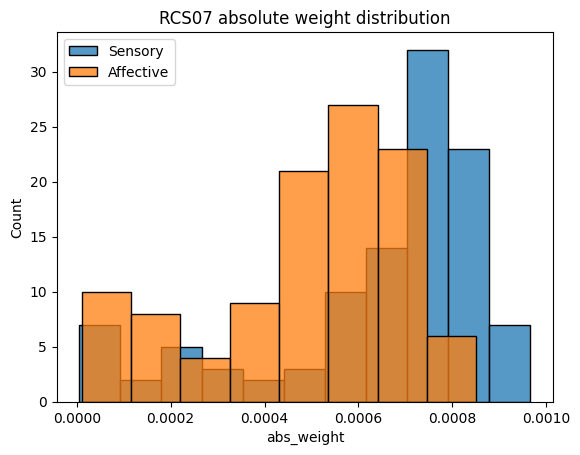

In [45]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_score, StratifiedKFold,permutation_test_score
from sklearn.dummy import DummyClassifier


ptIDs = ['RCS02', 'RCS05', 'RCS08']
pct = 30

cat_order = ['low', 'neutral', 'high']
color_map = {'low': '#3498DB', 'neutral': '#95A5A6', 'high': '#E74C3C'}

def split_dep_new(series, percent1, percent2=None):
    if percent2 == None: percent2 = percent1
    X = np.asarray(series)
    labels = pd.Series(['neutral'] * len(X), index=series.index)
    thresh_low = np.percentile(X, percent1)
    thresh_high = np.percentile(X, 100 - percent2)
    low = np.where(X <= thresh_low)[0]
    high = np.where(X >= thresh_high)[0]
    neutral = np.where((X > thresh_low) & (X < thresh_high))[0]
    labels.iloc[high] = 'high'
    labels.iloc[low] = 'low'
    return labels, len(high), len(neutral), len(low)

results = {}
# roi_select = [ 'L dlPFC','R MCC']
for ptID in ['RCS07']:
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_sens = subset['somatic_z']
    pc_aff = subset['affective_z']

    sens_cat, sens_high_num, sens_neu_num, sens_low_num = split_dep_new(pc_sens,50)
    aff_cat, aff_high_num, aff_neu_num, aff_low_num = split_dep_new(pc_aff, 30,30)

    print('Affective: ', ptID, sum(aff_cat == 'low'), sum(aff_cat == 'high'))
    print('Sensory: ', ptID, sum(sens_cat == 'low'), sum(sens_cat == 'high'))
    subset['aff_label'] = aff_cat
    subset['sens_label'] = sens_cat

    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_select = records_df['roi'].unique()
    merged = records_df.merge(subset,on='trial_idx')
    # merged['aff_label'] = aff_cat
    merged_filt1 = merged[(merged['r2']>=0.9) & (merged['sens_label']!='neutral') & (merged['roi'].isin(roi_select))]
    merged_filt2 = merged[(merged['r2']>=0.9) & (merged['aff_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # Predict affective high/low from somatic z-score, dropping neutral rows
    wide_aff = merged_filt2.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_aff.columns = [f'{feat}_{ch}' for feat, ch in wide_aff.columns]

    wide_sens = merged_filt1.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_sens.columns = [f'{feat}_{ch}' for feat, ch in wide_sens.columns]

    # if the r2 filter drops a channel for some trials, that trial will have NaNs after pivot — drop those trials
    wide_aff = wide_aff.dropna()
    wide_sens = wide_sens.dropna()

    
    X_aff = wide_aff
    y_aff = merged_filt2.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_aff.index, 'aff_label']

    X_sens = wide_sens
    y_sens = merged_filt1.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_sens.index, 'sens_label']

    n_components = 5

    clf_aff = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=42),
        LogisticRegressionCV(
            penalty='l2', solver='liblinear',
            cv=5, random_state=42,
            Cs=10, scoring='roc_auc', max_iter=1000,
        )
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores_aff = cross_val_score(clf_aff, X_aff, y_aff, cv=cv, scoring='roc_auc')
    accuracy_aff = cross_val_score(clf_aff, X_aff, y_aff, cv=cv, scoring='accuracy').mean()
    score, perm_scores, pvalue = permutation_test_score(clf_aff, X_aff, y_aff, cv=cv, scoring='roc_auc',n_permutations=500, random_state=42)
    print(f'Affective PCA({n_components}) out-of-sample AUC: %.3f ± %.3f' % (auc_scores_aff.mean(), auc_scores_aff.std()), 'accuracy: ', accuracy_aff)
    print(f'In n=500 permutation, Affective: true={score:.3f}, permuted mean={perm_scores.mean():.3f}, p={pvalue:.4f}')

    clf_sens = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=42),
        LogisticRegressionCV(
            penalty='l2', solver='liblinear',
            cv=5, random_state=42,
            Cs=10, scoring='roc_auc', max_iter=1000,
        )
    )
    auc_scores_sens = cross_val_score(clf_sens, X_sens, y_sens, cv=cv, scoring='roc_auc')
    accuracy_sens = cross_val_score(clf_sens, X_sens, y_sens, cv=cv, scoring='accuracy').mean()
    score, perm_scores, pvalue = permutation_test_score(clf_sens, X_sens, y_sens, cv=cv, scoring='roc_auc',n_permutations=500, random_state=42)
        
    print(f'Sensory PCA({n_components}) out-of-sample AUC: %.3f ± %.3f' % (auc_scores_sens.mean(), auc_scores_sens.std()),'accuracy: ', accuracy_sens)
    print(f'In n=500 permutation, Sensory: true={score:.3f}, permuted mean={perm_scores.mean():.3f}, p={pvalue:.4f}')

    print('Starting full-sample PCA for coefficients:')
    
    coef_df_aff, pipe_aff, score_aff = get_coef_df(X_aff, y_aff, n_components=n_components, label='Affective')
    coef_df_sens, pipe_sens, score_sens = get_coef_df(X_sens, y_sens, n_components=n_components, label='Sensory')

    sns.histplot(coef_df_sens['abs_weight'],label='Sensory')
    sns.histplot(coef_df_aff['abs_weight'],label='Affective')
    plt.legend()
    plt.title(f'{ptID} absolute weight distribution')

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

n_components_list = [3,5,10]
coef_final = None
score_final = 0
n_comp_final = 0
for n_components in n_components_list:
    # 1. fit on all data
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=42),
        LogisticRegressionCV(
            penalty="l2",
            solver="liblinear",
            Cs=10,
            max_iter=1000,
            random_state=42,scoring='roc_auc'
        )
    )

    pipe.fit(X_aff, y_aff)
    score = pipe.score(X_aff, y_aff)
    print(score)

    # 2. extract each step
    scaler = pipe.named_steps["standardscaler"]
    pca = pipe.named_steps["pca"]
    logreg = pipe.named_steps["logisticregressioncv"]

    # 3. logistic coefficient in PCA space
    beta_pc = logreg.coef_.ravel()

    # 4. back-project to original feature space
    beta_feature = pca.components_.T @ beta_pc

    # 5. organize into dataframe
    coef_df = pd.DataFrame({
        "feature": X_aff.columns,
        "weight": beta_feature,
        "abs_weight": np.abs(beta_feature)
    }).sort_values("abs_weight", ascending=False)

    if score>score_final:
        score_final = score
        coef_final = coef_df
        n_comp_final = n_components
    print(coef_df.head(20))

0.5727272727272728
                 feature    weight  abs_weight
19     exponent_L PINS_2 -0.021486    0.021486
45      exponent_R OFC_4 -0.019693    0.019693
49      exponent_R OFC_8 -0.019543    0.019543
43      exponent_R OFC_2 -0.019279    0.019279
20     exponent_L PINS_3 -0.018972    0.018972
10      exponent_L OFC_1 -0.018618    0.018618
48      exponent_R OFC_7 -0.016812    0.016812
17      exponent_L OFC_8 -0.016421    0.016421
22     exponent_L PINS_5 -0.016405    0.016405
12      exponent_L OFC_3 -0.014882    0.014882
4        exponent_L IC_3  0.014872    0.014872
83       offset_L PINS_2 -0.014318    0.014318
79        offset_L OFC_6  0.013923    0.013923
87       offset_L THAL_1  0.013832    0.013832
8       exponent_L MCC_1  0.012966    0.012966
0   exponent_L Caudate_1  0.012788    0.012788
64    offset_L Caudate_1  0.012763    0.012763
3        exponent_L IC_2  0.012582    0.012582
21     exponent_L PINS_4 -0.012496    0.012496
44      exponent_R OFC_3 -0.012197    0.0

<Axes: title={'center': 'RCS07 exponent vs offset in top 20 features'}, xlabel='Type', ylabel='#occurrence of exp vs offset'>

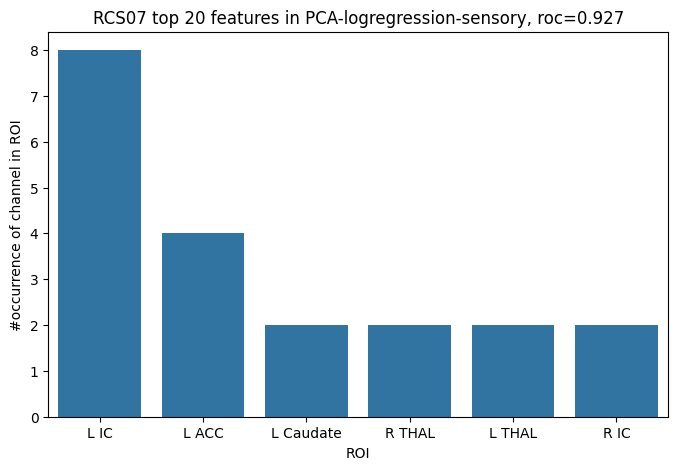

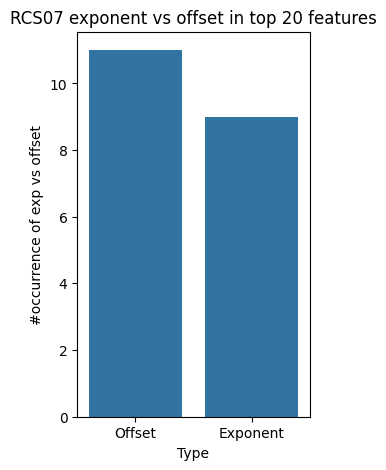

In [44]:
top_k = 20
coef_final = coef_df_sens
score_final = score_sens
tmp = coef_final.copy()
tmp["abs_weight"] = tmp["weight"].abs()

tmp["ROI"] = (
    tmp["feature"]
      .str.replace("exponent_", "", regex=False)
      .str.replace("offset_", "", regex=False)
      .str.replace(r"_\d+$", "", regex=True)
)

# Top K feature
top = tmp.nlargest(top_k, "abs_weight")
top["Type"] = np.where(
    top["feature"].str.startswith("exponent"),
    "Exponent",
    "Offset"
)

# occurrence
occurrence = (
    top["ROI"]
    .value_counts()
    .sort_values(ascending=False)
)
type_count = top["Type"].value_counts()
plt.figure(figsize=(8,5))
plt.title(f'{ptID} top {top_k} features in PCA-logregression-sensory, roc={score_final:.03f}')
plt.ylabel('#occurrence of channel in ROI')
sns.barplot(occurrence)

plt.figure(figsize=(3,5))
plt.title(f'{ptID} exponent vs offset in top {top_k} features')
plt.ylabel('#occurrence of exp vs offset')
sns.barplot(type_count)

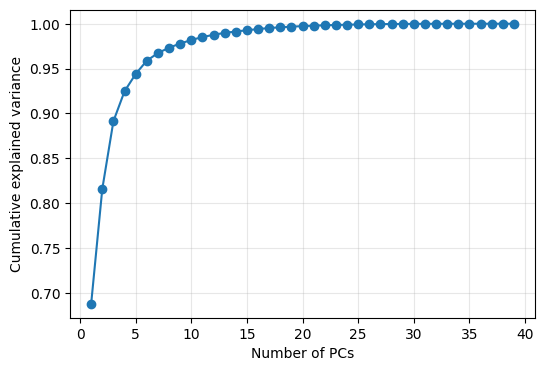

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_aff)

# Fit PCA with all components
pca = PCA()
pca.fit(X_scaled)

# Explained variance
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(cum_evr)+1), cum_evr, '-o')
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.grid(alpha=0.3)
plt.show()


In [7]:
from sklearn.linear_model import LogisticRegression

results = {}

for n_pc in [3,5,10]:

    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_pc, random_state=42),
        LogisticRegressionCV(
            penalty="l2",
            solver="liblinear",
            Cs=10,
            max_iter=5000,
            random_state=42
        )
    )

    pipe.fit(X_aff, y_aff)

    scaler = pipe.named_steps["standardscaler"]
    pca = pipe.named_steps["pca"]
    clf = pipe.named_steps["logisticregressioncv"]

    beta_pc = clf.coef_.ravel()

    # back projection
    beta_feature = (pca.components_.T @ beta_pc) / scaler.scale_

    results[n_pc] = pd.Series(
        beta_feature,
        index=X_aff.columns,
        name=f"PC{n_pc}"
    )

coef_df = pd.concat(results.values(), axis=1)
coef_df.columns = results.keys()

coef_df.head()

,3,5,10
exponent_L AINS_1,-0.103239,-0.025643,-0.141607
exponent_L AINS_2,-0.009548,-0.014717,-0.155081
exponent_L AINS_3,-0.014454,0.000872,-0.068705
exponent_L AINS_4,-0.055709,-0.010991,-0.030586
exponent_L IC_1,0.039438,0.008295,0.054242
